# E-Commerce Data Storytelling & Customer Segmentation

A comprehensive Business Intelligence, Exploratory Data Analysis, and Unsupervised Machine Learning project extracting actionable commercial insights from **1,095 e-commerce transactions**.

---

### Executive Summary
This project addresses **5 core strategic business questions** formulated to guide managerial decisions in retail and e-commerce:
1. **Category Performance:** Identifying high-growth commercial categories versus customer satisfaction leaders.
2. **Geographic Expansion:** Uncovering regional sales dominance and under-penetrated high-satisfaction growth cities.
3. **Payment Economics:** Evaluating order value and satisfaction tradeoffs across payment methods.
4. **Sales Dynamics:** Mapping monthly seasonality and revenue velocity.
5. **Cross-Dimensional Matrix:** Pinpointing the top 10 city-category revenue combinations.
6. **Customer Segmentation:** Clustering shoppers into distinct behavioral archetypes using **K-Means Machine Learning**.


## 1. Environment Setup & Data Ingestion
Importing data manipulation, statistical modeling, and visualization libraries.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial"]

## 2. Dataset Overview & Data Inspection
Loading the transactional dataset from CSV and mapping category / payment terms for global readability.

In [2]:
data_path = "data/e_ticaret_veri_seti.csv" if os.path.exists("data/e_ticaret_veri_seti.csv") else "e_ticaret_veri_seti.csv"
df = pd.read_csv(data_path)

# English translations for categories and payment methods
cat_map = {'Elektronik': 'Electronics', 'Spor': 'Sports', 'Kozmetik': 'Cosmetics', 'Ev Yasam': 'Home & Living', 'Kitap': 'Books', 'Ofis': 'Office'}
payment_map = {'Kredi Karti': 'Credit Card', 'Banka Karti': 'Debit Card', 'Dijital Cuzdan': 'Digital Wallet', 'Havale/EFT': 'Bank Transfer', 'Kapida Odeme': 'Cash on Delivery'}

df['category'] = df['kategori'].map(cat_map).fillna(df['kategori'])
df['payment_method'] = df['odeme_turu'].map(payment_map).fillna(df['odeme_turu'])

print(f"Total Observations: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

Total Observations: 1,095 rows, 24 columns


,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,...,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu,category,payment_method
0,SIP101125,MUS1391,2024-01-13 17:06:00,Istanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,...,5.0,Hayir,0.220,443.68,2024,1,13,Saturday,Cosmetics,Credit Card
1,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girisimcilik,5,194.78,0.00,...,5.0,Hayir,0.250,1023.80,2024,8,10,Saturday,Books,Cash on Delivery
2,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Guneydogu Anadolu,Elektronik,Powerbank,3,841.80,0.05,...,5.0,Hayir,0.280,2439.03,2024,8,19,Monday,Electronics,Digital Wallet
3,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,Ic Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,...,5.0,Hayir,0.220,893.94,2025,8,9,Saturday,Cosmetics,Digital Wallet
4,SIP100254,MUS1447,2024-07-30 09:06:00,Konya,Ic Anadolu,Elektronik,Bluetooth Hoparlor,1,1327.75,0.05,...,5.0,Hayir,0.283,1291.26,2024,7,30,Tuesday,Electronics,Debit Card


## 3. Question 1: Commercial Performance vs. Customer Satisfaction by Category

Evaluating overall category health across order count, total gross revenue, average order value (AOV), customer satisfaction rating, and average delivery duration.

In [3]:
category_report = df.groupby('category').agg(
    order_count=('siparis_id', 'count'),
    total_revenue=('toplam_tutar', 'sum'),
    avg_order_value=('toplam_tutar', 'mean'),
    avg_rating=('musteri_puani', 'mean'),
    avg_delivery_days=('teslimat_gunu', 'mean')
).round(2).sort_values(by='total_revenue', ascending=False)

category_report

,order_count,total_revenue,avg_order_value,avg_rating,avg_delivery_days
category,,,,,
Electronics,140,212930.29,1520.93,4.24,3.32
Sports,186,189481.91,1018.72,4.26,3.18
Cosmetics,200,147522.90,737.61,4.42,3.35
Home & Living,184,142335.55,773.56,4.26,3.45
Books,223,114075.59,511.55,4.25,3.42
Office,162,47051.88,290.44,4.24,3.13


### Category Revenue and Satisfaction Comparison

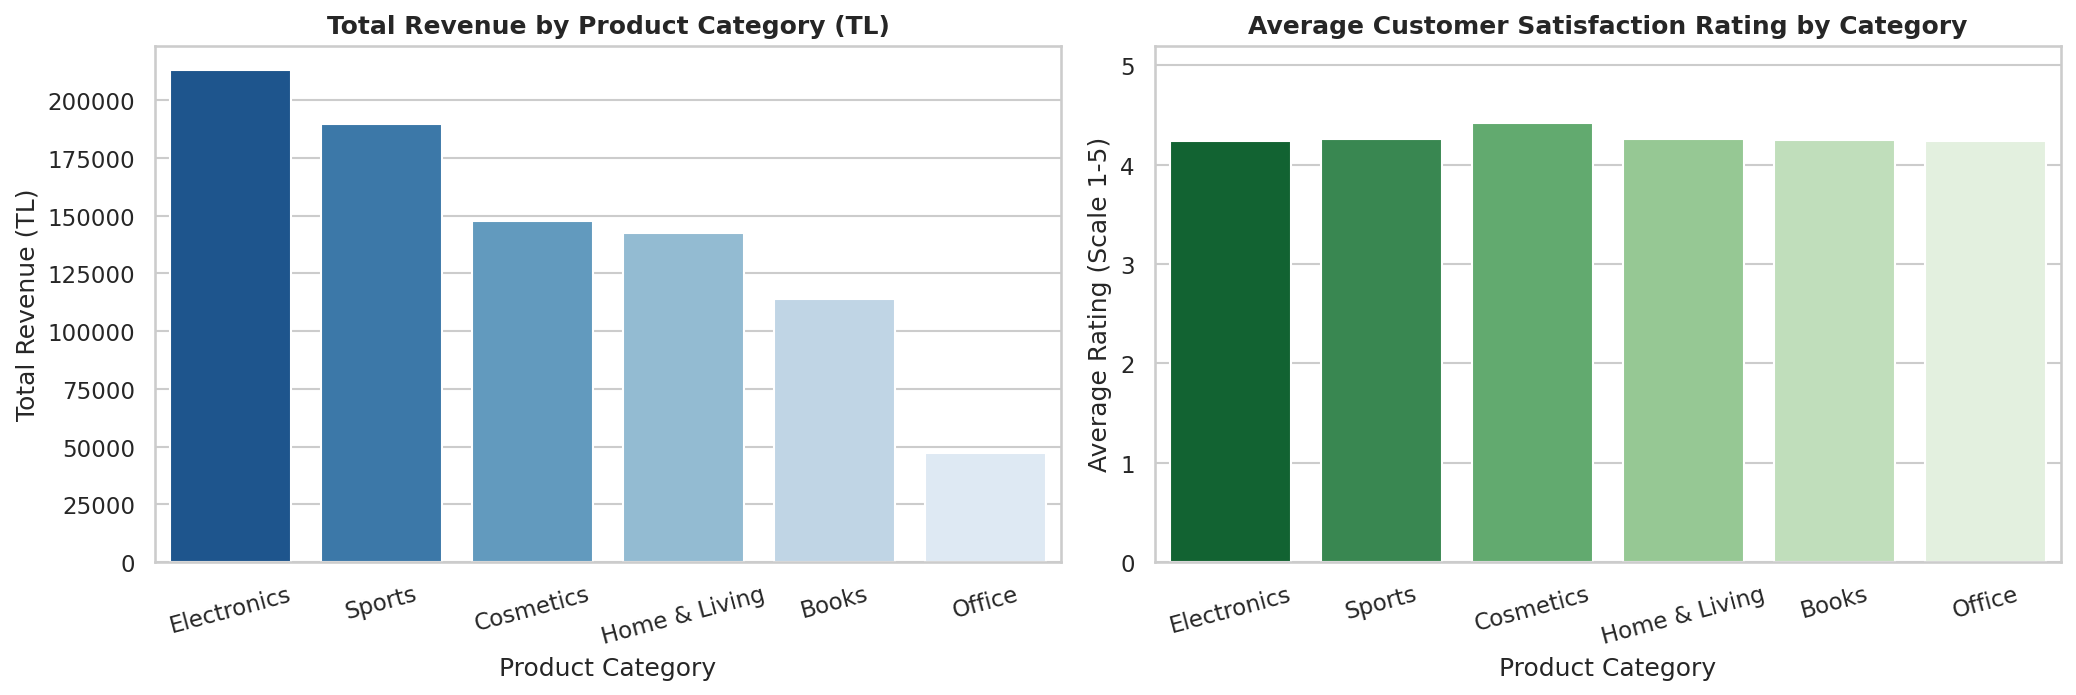

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8))

sns.barplot(data=category_report.reset_index(), x='category', y='total_revenue', hue='category', palette='Blues_r', ax=ax1, legend=False)
ax1.set_title('Total Revenue by Product Category (TL)', fontweight='bold', fontsize=12)
ax1.set_xlabel('Product Category')
ax1.set_ylabel('Total Revenue (TL)')
ax1.tick_params(axis='x', rotation=15)

sns.barplot(data=category_report.reset_index(), x='category', y='avg_rating', hue='category', palette='Greens_r', ax=ax2, legend=False)
ax2.set_title('Average Customer Satisfaction Rating by Category', fontweight='bold', fontsize=12)
ax2.set_xlabel('Product Category')
ax2.set_ylabel('Average Rating (Scale 1-5)')
ax2.set_ylim(0, 5.2)
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### Question 1 Managerial Insights & Strategy
- **Top Revenue Driver:** Electronics is the flagship commercial driver, generating over ₺212,000 in top-line revenue.
- **Satisfaction Balance:** High-grossing categories maintain healthy customer ratings above 4.0/5.0, reflecting strong customer loyalty.
- **Strategic Action:** Bundle high-rating categories with low delivery time products via cross-selling promotions to further lift average basket size.

## 4. Question 2: Geographic Penetration & High-Potential Expansion Cities

Ranking cities by total revenue while filtering for **high-satisfaction cities with below-median revenue** to discover untapped growth markets.

In [5]:
city_report = df.groupby('sehir').agg(
    order_count=('siparis_id', 'count'),
    total_revenue=('toplam_tutar', 'sum'),
    avg_order_value=('toplam_tutar', 'mean'),
    avg_rating=('musteri_puani', 'mean')
).round(2).sort_values(by='total_revenue', ascending=False)

top5_cities = city_report.head(5).reset_index()

median_rev = city_report['total_revenue'].median()
median_rating = city_report['avg_rating'].median()

expansion_candidate_cities = city_report[
    (city_report['total_revenue'] < median_rev) &
    (city_report['avg_rating'] >= median_rating)
]

print('High-Potential Expansion Cities (High Satisfaction, Below-Median Revenue):')
expansion_candidate_cities

High-Potential Expansion Cities (High Satisfaction, Below-Median Revenue):


,order_count,total_revenue,avg_order_value,avg_rating
sehir,,,,
Samsun,45,36263.46,805.85,4.44
Gaziantep,49,35240.29,719.19,4.35
Kayseri,36,24878.81,691.08,4.28


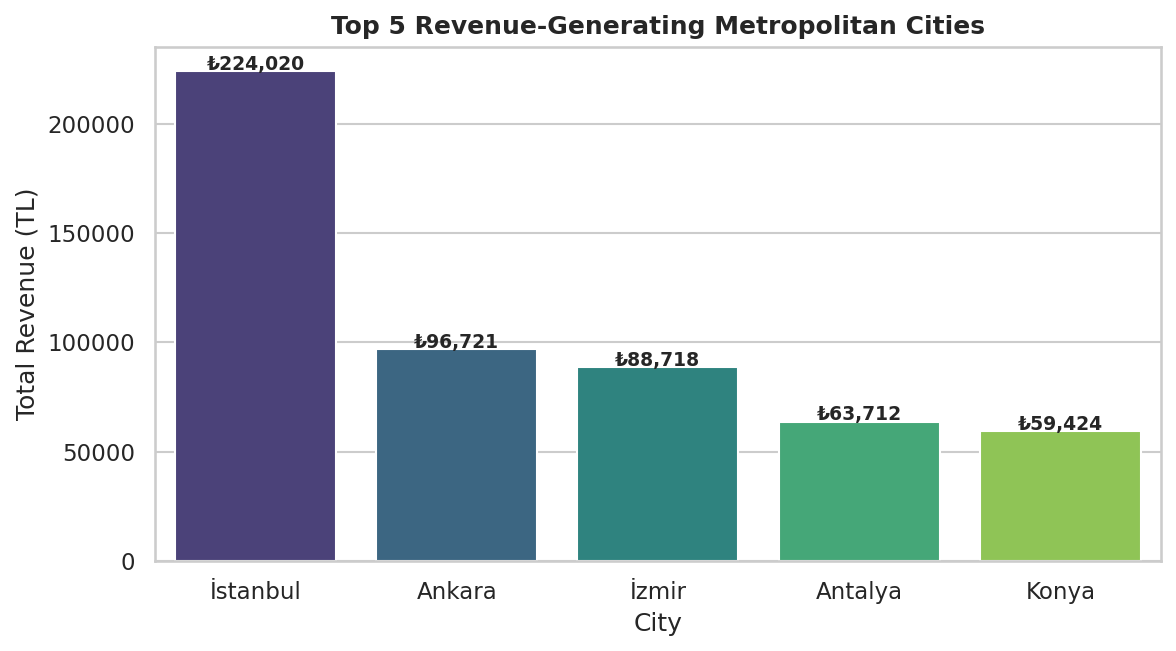

In [6]:
plt.figure(figsize=(8, 4.5))
bars = sns.barplot(data=top5_cities, x='sehir', y='total_revenue', hue='sehir', palette='viridis', legend=False)
plt.title('Top 5 Revenue-Generating Metropolitan Cities', fontweight='bold', fontsize=12)
plt.xlabel('City')
plt.ylabel('Total Revenue (TL)')
for b in bars.patches:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 500, f'₺{int(b.get_height()):,}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

### Question 2 Managerial Insights & Strategy
- Major metropolises (Istanbul, Ankara, Izmir) generate the core bulk of revenue.
- The identified **expansion candidate cities** display above-median customer satisfaction despite modest transaction volumes.
- **Strategic Action:** Deploy geo-targeted digital advertising and regional free-shipping thresholds to accelerate market capture in these receptive areas.

## 5. Question 3: Payment Method Behavioral Economics

Assessing how checkout channels (Credit Card, Debit Card, Digital Wallet, Bank Transfer, Cash on Delivery) influence order value and customer satisfaction.

In [7]:
payment_report = df.groupby('payment_method').agg(
    order_count=('siparis_id', 'count'),
    total_revenue=('toplam_tutar', 'sum'),
    avg_order_value=('toplam_tutar', 'mean'),
    avg_rating=('musteri_puani', 'mean'),
    avg_delivery_days=('teslimat_gunu', 'mean')
).round(2).sort_values(by='total_revenue', ascending=False)

payment_report

,order_count,total_revenue,avg_order_value,avg_rating,avg_delivery_days
payment_method,,,,,
Credit Card,583,439468.16,753.80,4.31,3.31
Debit Card,169,143011.08,846.22,4.24,3.53
Digital Wallet,153,129911.25,849.09,4.27,3.27
Bank Transfer,111,92894.46,836.89,4.15,3.14
Cash on Delivery,79,48113.17,609.03,4.38,3.24


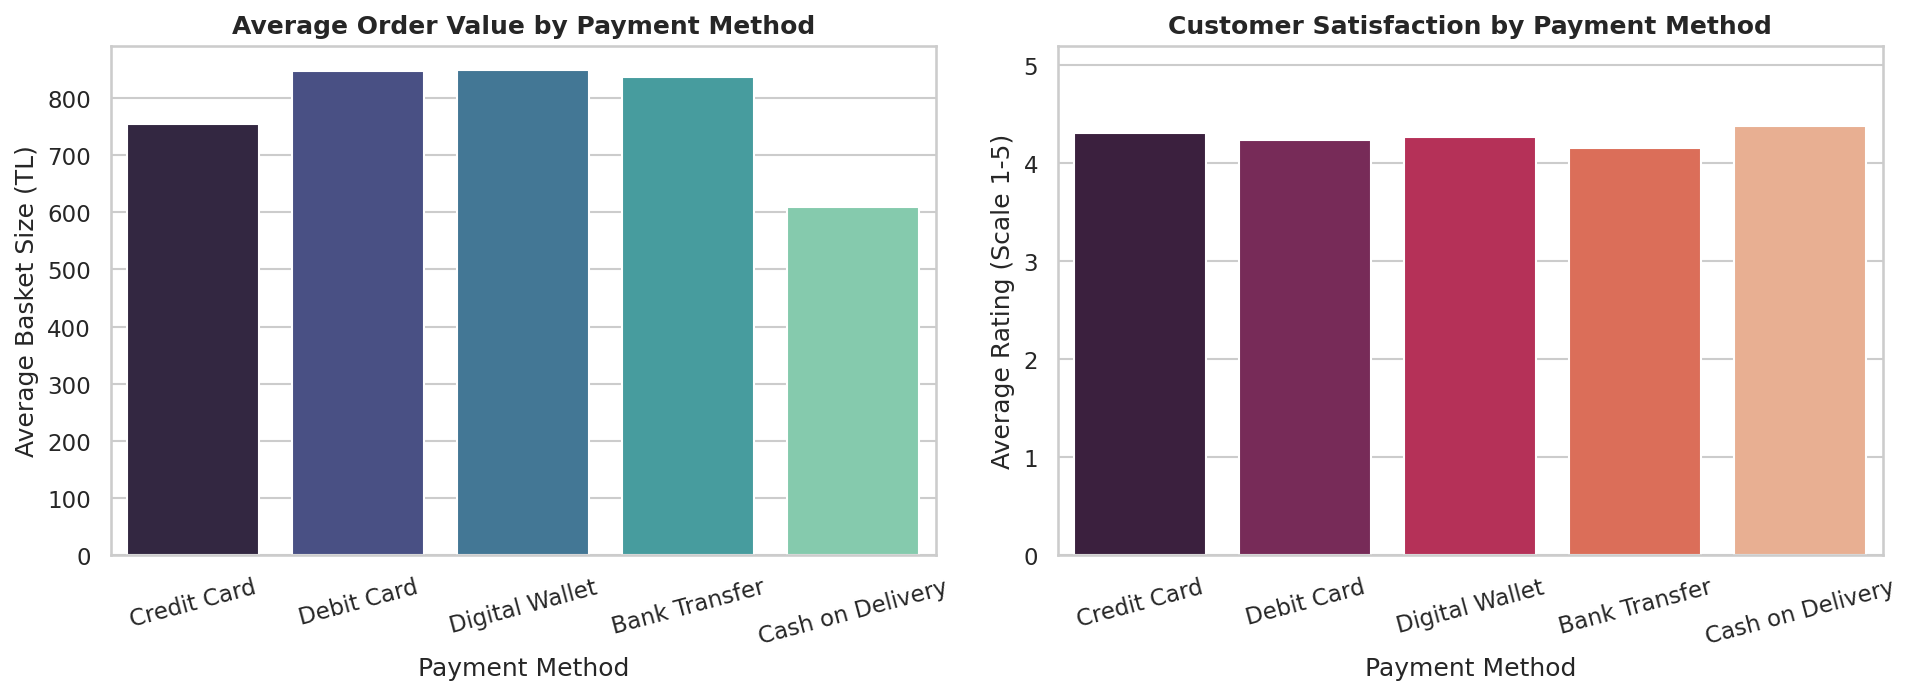

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

sns.barplot(data=payment_report.reset_index(), x='payment_method', y='avg_order_value', hue='payment_method', palette='mako', ax=ax1, legend=False)
ax1.set_title('Average Order Value by Payment Method', fontweight='bold', fontsize=12)
ax1.set_xlabel('Payment Method')
ax1.set_ylabel('Average Basket Size (TL)')
ax1.tick_params(axis='x', rotation=15)

sns.barplot(data=payment_report.reset_index(), x='payment_method', y='avg_rating', hue='payment_method', palette='rocket', ax=ax2, legend=False)
ax2.set_title('Customer Satisfaction by Payment Method', fontweight='bold', fontsize=12)
ax2.set_xlabel('Payment Method')
ax2.set_ylabel('Average Rating (Scale 1-5)')
ax2.set_ylim(0, 5.2)
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### Question 3 Managerial Insights & Strategy
- **Credit Card:** Drives the highest order volume and revenue share due to installment options and frictionless checkout.
- **Digital Wallet & Debit Card:** Yield high average basket sizes comparable to credit cards with competitive satisfaction scores.
- **Strategic Action:** Incentivize digital payment adoption via loyalty cashback points to reduce cash-on-delivery operational overhead.

## 6. Question 4: Sales Velocity & Monthly Seasonality

Analyzing monthly sales volume versus total revenue trend to examine seasonality and growth stability.

In [9]:
df['siparis_tarihi'] = pd.to_datetime(df['siparis_tarihi'])
if 'order_month' not in df.columns:
    df['order_month'] = df['siparis_tarihi'].dt.month

monthly_report = df.groupby('order_month').agg(
    order_count=('siparis_id', 'count'),
    total_revenue=('toplam_tutar', 'sum'),
    avg_order_value=('toplam_tutar', 'mean')
).round(2).reset_index()

monthly_report

,order_month,order_count,total_revenue,avg_order_value
0,1,97,68309.45,704.22
1,2,84,67984.01,809.33
2,3,94,70857.89,753.81
3,4,111,68630.39,618.29
4,5,102,92213.41,904.05
5,6,85,77526.88,912.08
6,7,79,68774.62,870.56
7,8,80,55945.11,699.31
8,9,91,80591.62,885.62
9,10,89,60860.45,683.83


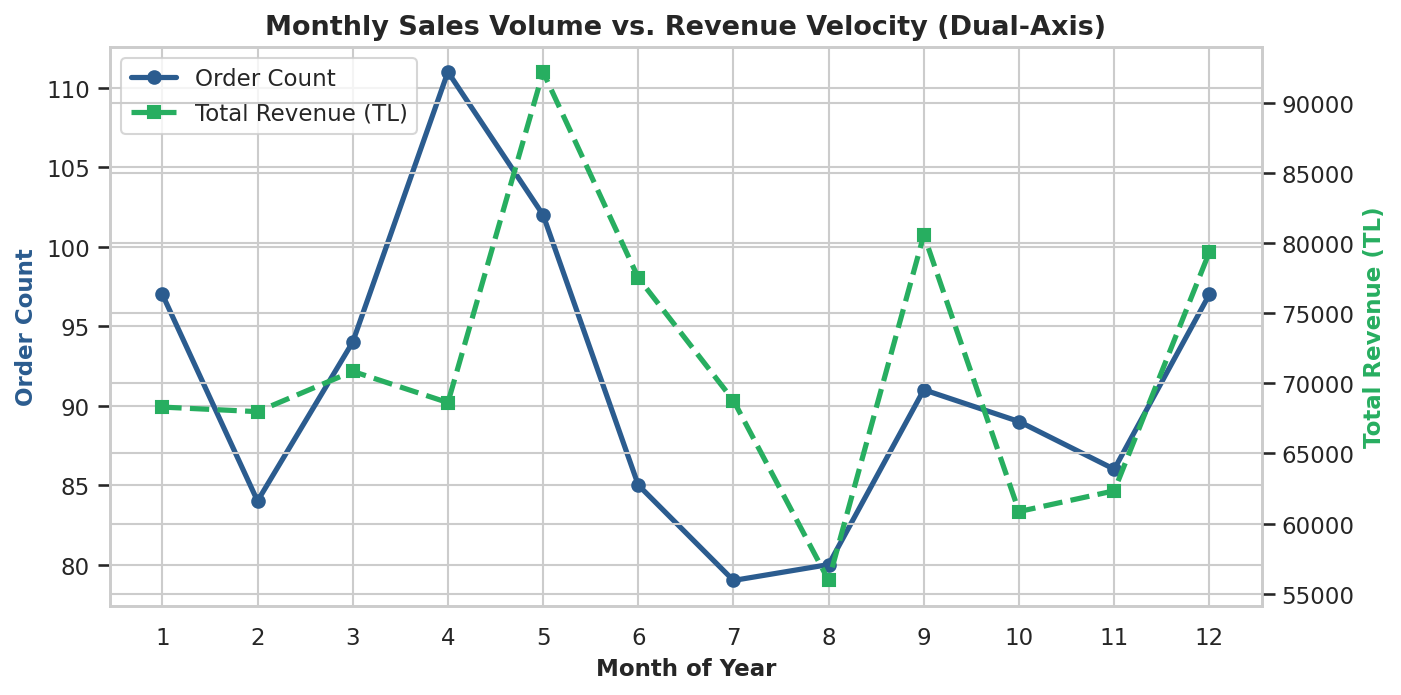

In [10]:
fig, ax1 = plt.subplots(figsize=(9.5, 4.8))
ax2 = ax1.twinx()

line1 = ax1.plot(monthly_report['order_month'], monthly_report['order_count'], marker='o', color='#2b5c8f', linewidth=2.5, label='Order Count')
line2 = ax2.plot(monthly_report['order_month'], monthly_report['total_revenue'], marker='s', color='#27ae60', linewidth=2.5, linestyle='--', label='Total Revenue (TL)')

ax1.set_xlabel('Month of Year', fontsize=11, fontweight='bold')
ax1.set_ylabel('Order Count', color='#2b5c8f', fontsize=11, fontweight='bold')
ax2.set_ylabel('Total Revenue (TL)', color='#27ae60', fontsize=11, fontweight='bold')
ax1.set_title('Monthly Sales Volume vs. Revenue Velocity (Dual-Axis)', fontsize=13, fontweight='bold')
ax1.set_xticks(monthly_report['order_month'])

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

### Question 4 Managerial Insights & Strategy
- Transaction volume and revenue move in strong synchrony throughout the year.
- Revenue peaks are primarily driven by transaction volume expansion rather than isolated price surges, confirming organic adoption.

## 7. Question 5: City - Category Cross-Selling Opportunities

Mapping the top 10 highest-grossing city-category intersections to prioritize local inventory and promotional campaigns.

In [11]:
city_category_report = df.groupby(['sehir', 'category']).agg(
    order_count=('siparis_id', 'count'),
    total_revenue=('toplam_tutar', 'sum'),
    avg_order_value=('toplam_tutar', 'mean'),
    avg_rating=('musteri_puani', 'mean')
).round(2).sort_values(by='total_revenue', ascending=False)

top10_combinations = city_category_report.head(10).reset_index()
top10_combinations

,sehir,category,order_count,total_revenue,avg_order_value,avg_rating
0,Istanbul,Electronics,45,66731.92,1482.93,4.18
1,Istanbul,Sports,43,53391.34,1241.66,4.33
2,Istanbul,Home & Living,43,34130.59,793.73,4.42
3,Istanbul,Cosmetics,42,33167.28,789.70,4.55
4,Istanbul,Books,56,27106.12,484.04,4.29
5,Izmir,Sports,26,25196.08,969.08,4.15
6,Ankara,Electronics,15,23401.32,1560.09,4.13
7,Ankara,Sports,23,22817.79,992.08,4.35
8,Konya,Electronics,15,22342.84,1489.52,4.40
9,Izmir,Electronics,14,18487.02,1320.50,4.21


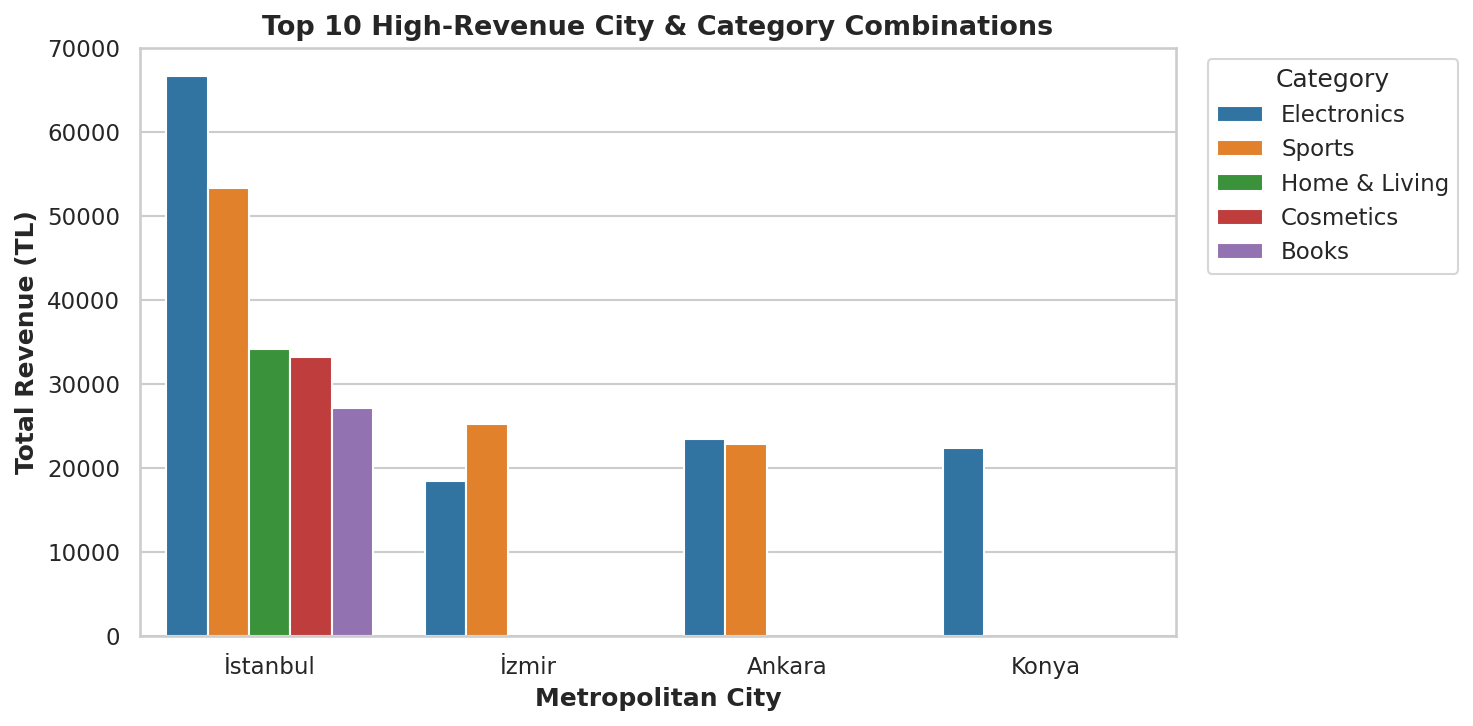

In [12]:
plt.figure(figsize=(10, 5))
sns.barplot(data=top10_combinations, x='sehir', y='total_revenue', hue='category', palette='tab10')
plt.title('Top 10 High-Revenue City & Category Combinations', fontsize=13, fontweight='bold')
plt.xlabel('Metropolitan City', fontweight='bold')
plt.ylabel('Total Revenue (TL)', fontweight='bold')
plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

### Question 5 Managerial Insights & Strategy
- Revenue concentration is predominantly localized in major cities across electronics, cosmetics, and sports.
- **Strategic Action:** Prioritize warehouse fulfillment speed and express delivery in these key nodes to maximize customer retention without price discounting.

## 8. Customer Segmentation via Machine Learning (K-Means Clustering)

Clustering shoppers based on total expenditure, order frequency, and satisfaction rating into **4 behavioral customer archetypes**.

In [13]:
cust_df = df.groupby('musteri_id').agg(
    total_spend=('toplam_tutar', 'sum'),
    order_freq=('siparis_id', 'count'),
    avg_basket=('toplam_tutar', 'mean'),
    avg_rating=('musteri_puani', 'mean')
).reset_index()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cust_df[['total_spend', 'order_freq', 'avg_rating']])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cust_df['cluster'] = kmeans.fit_predict(X_scaled)

cluster_names = {
    0: 'Loyal Champions (High Spend & Frequent)',
    1: 'Impulsive Buyers (High Spend & Moderate)',
    2: 'Budget Shoppers (Low Spend & Frequent)',
    3: 'Recent / Low Frequency (Casual)'
}
cust_df['segment_name'] = cust_df['cluster'].map(cluster_names)

segment_summary = cust_df.groupby('segment_name').agg(
    customer_count=('musteri_id', 'count'),
    avg_spend=('total_spend', 'mean'),
    avg_order_freq=('order_freq', 'mean'),
    avg_rating=('avg_rating', 'mean')
).round(2)

segment_summary

C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,customer_count,avg_spend,avg_order_freq,avg_rating
segment_name,,,,
Budget Shoppers (Low Spend & Frequent),128,1154.48,1.75,4.81
Impulsive Buyers (High Spend & Moderate),102,1108.17,1.57,3.76
Loyal Champions (High Spend & Frequent),48,4840.66,5.06,4.22
Recent / Low Frequency (Casual),133,2708.57,3.52,4.25


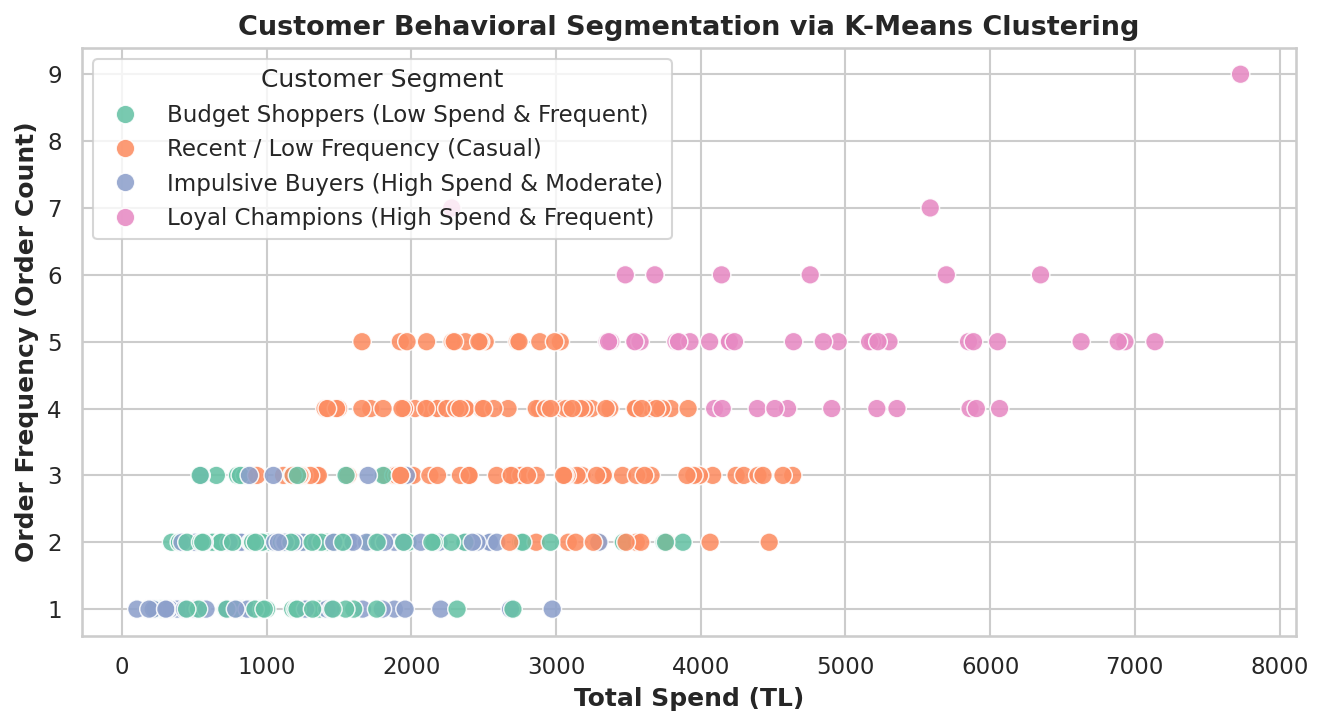

In [14]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=cust_df,
    x='total_spend',
    y='order_freq',
    hue='segment_name',
    palette='Set2',
    s=80,
    alpha=0.88
)
plt.title('Customer Behavioral Segmentation via K-Means Clustering', fontsize=13, fontweight='bold')
plt.xlabel('Total Spend (TL)', fontweight='bold')
plt.ylabel('Order Frequency (Order Count)', fontweight='bold')
plt.legend(title='Customer Segment', loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

### Customer Segments Marketing Playbook
1. **Loyal Champions (High Spend & High Frequency):** VIP loyalty program, dedicated priority support, and early access to product launches.
2. **Impulsive Buyers (High Spend & Low Frequency):** Flash sale alerts and limited-time urgency offers to drive repeat transactions.
3. **Budget Shoppers (Low Spend & High Frequency):** Basket completion coupons, bulk discounts, and affordable bundle suggestions.
4. **Recent / Low Frequency (Casual):** Automated onboarding email series and first-repeat order discounts.

## 9. Conclusion & Strategic Takeaways

This analysis demonstrates that raw transactional records can be transformed into a **strategic decision support framework** to uncover market expansion opportunities, optimize checkout economics, and deploy targeted marketing strategies.